1.import libraries

In [ ]:


import pandas as pd


df = pd.read_csv("transactions.csv")

print(df.head())


                         Transaction ID       Timestamp      Sender Name  \
0  4d3db980-46cd-4158-a812-dcb77055d0d2  22-06-24 04:06        Tiya Mall   
1  099ee548-2fc1-4811-bf92-559c467ca792  19-06-24 06:04  Mohanlal Bakshi   
2  d4c05732-6b1b-4bab-90b9-efe09d252b99  04-06-24 04:56      Kismat Bora   
3  e8df92ee-8b04-4133-af5a-5f412180c8ab  09-06-24 09:56    Ayesha Korpal   
4  e7d675d3-04f1-419c-a841-7a04662560b7  25-06-24 08:38      Jivin Batta   

           Sender UPI ID   Receiver Name     Receiver UPI ID  Amount (INR)  \
0      4161803452@okaxis  Mohanlal Golla    7776849307@okybl       3907.34   
1      8908837379@okaxis  Mehul Sankaran   7683454560@okaxis       8404.55   
2       4633654150@okybl       Diya Goel  2598130823@okicici        941.88   
3  7018842771@okhdfcbank    Rhea Kothari   2246623650@okaxis       8926.00   
4       1977143985@okybl     Baiju Issac    5245672729@okybl       2800.55   

    Status  
0   FAILED  
1  SUCCESS  
2  SUCCESS  
3  SUCCESS  
4  SUCCES

2.Encoding Categorical Column

In [ ]:

df['Status'] = df['Status'].map({'SUCCESS':1, 'FAILED':0})

print(df['Status'].head())


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Status, dtype: float64


3.Encoding UPI IDs and Extracting Hour Feature

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sender UPI ID'] = le.fit_transform(df['Sender UPI ID'])
df['Receiver UPI ID'] = le.fit_transform(df['Receiver UPI ID'])

# Timestamp → Hour
df['Hour'] = pd.to_datetime(df['Timestamp'], errors='coerce').dt.hour


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_6668\3161055043.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Timestamp'], errors='coerce').dt.hour


4.Train-Test Split for Model Building

In [5]:
from sklearn.model_selection import train_test_split

X = df[['Amount (INR)', 'Sender UPI ID', 'Receiver UPI ID', 'Hour']]
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


5.Lable encoder

In [ ]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sender UPI ID'] = le.fit_transform(df['Sender UPI ID'])
df['Receiver UPI ID'] = le.fit_transform(df['Receiver UPI ID'])


6."Timestamp Conversion to Hour Feature"

In [ ]:

df['Hour'] = pd.to_datetime(df['Timestamp'], format='%d-%m-%y %H:%M', errors='coerce').dt.hour


7.Checking for Missing Values (NaN)

In [10]:
#check for NaN values
print(df.isnull().sum())


Transaction ID        0
Timestamp             0
Sender Name           0
Sender UPI ID         0
Receiver Name         0
Receiver UPI ID       0
Amount (INR)          0
Status             1000
Hour                  0
dtype: int64


8.Dropping Rows with Missing Values

In [11]:
df = df.dropna()


9.Data Preprocessing and Train-Test Split

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
df = pd.read_csv("transactions.csv")

# Encode categorical UPI IDs
le = LabelEncoder()
df['Sender UPI ID'] = le.fit_transform(df['Sender UPI ID'])
df['Receiver UPI ID'] = le.fit_transform(df['Receiver UPI ID'])

# Convert Status column to numeric
df['Status'] = df['Status'].map({'SUCCESS':1, 'FAILED':0})

# Extract hour from timestamp
df['Hour'] = pd.to_datetime(df['Timestamp'], errors='coerce').dt.hour

# Select features and target
X = df[['Amount (INR)', 'Sender UPI ID', 'Receiver UPI ID', 'Hour']]
y = df['Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_6668\2852483723.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Timestamp'], errors='coerce').dt.hour


              precision    recall  f1-score   support

           0       0.53      0.58      0.55        97
           1       0.56      0.51      0.54       103

    accuracy                           0.55       200
   macro avg       0.55      0.55      0.54       200
weighted avg       0.55      0.55      0.54       200



10.Model Prediction on Test Data

In [20]:
#prediction
y_pred = model.predict(X_test)
print(y_pred)


[1 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 1 1 0 0 1 0 0 1 1 1 1 1 1 0
 1 0 1 0 0 1 1 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 0 1
 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 1
 1 0 1 1 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 1 1 1 1 0 1
 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1 0 0 1 0 1 1 0
 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0]


11.confusion matrix

In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)




Confusion Matrix:
 [[56 41]
 [50 53]]


In [ ]:
12.Confusion Matrix Visualization

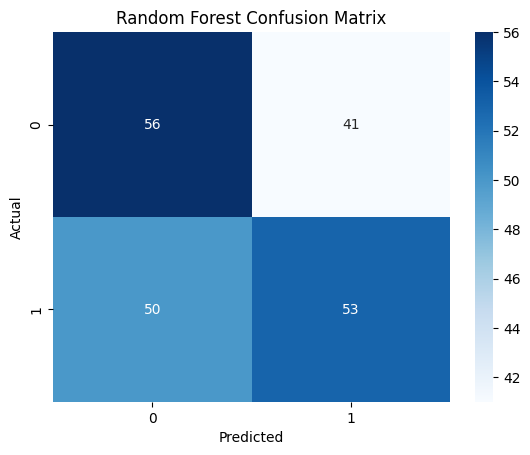

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualization
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [ ]:
13.Comparing Train vs Test Accuracy

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("transactions.csv")

le = LabelEncoder()
df['Sender UPI ID'] = le.fit_transform(df['Sender UPI ID'])
df['Receiver UPI ID'] = le.fit_transform(df['Receiver UPI ID'])

df['Status'] = df['Status'].map({'SUCCESS':1, 'FAILED':0})

df['Hour'] = pd.to_datetime(df['Timestamp'], errors='coerce').dt.hour


X = df[['Amount (INR)', 'Sender UPI ID', 'Receiver UPI ID', 'Hour']]
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_11100\2533349593.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Timestamp'], errors='coerce').dt.hour


Train Accuracy: 1.0
Test Accuracy: 0.545


14.Model Evaluation using Classification Report

In [21]:
#Evaluation
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.53      0.58      0.55        97
           1       0.56      0.51      0.54       103

    accuracy                           0.55       200
   macro avg       0.55      0.55      0.54       200
weighted avg       0.55      0.55      0.54       200

